### 工作進度  
* 新的股票投資筆記Jupyter Notebook架構：  
  - 第一部分：工作進度  
    * 執行日常程序：  
      - 引入模組與定義公用函式。  
      - 更新量化技術分析資料庫。  
      - 建立「解盤」物件。  
    * 量化技術分析系統修改紀錄。
    * [K線追擊週報](https://smart.businessweekly.com.tw/e-subscription/project?c=GROUP00014146&p=PROD000019311)－[日報](https://mega.nz/folder/a85wHKwK#SA6HACStdXRvMsLd2Ct0tQ)(以[剪報](https://zh.wikipedia.org/zh-tw/%E5%89%AA%E5%A0%B1)方式紀錄LINE群組資訊)連結。  
    * 日常程序以外的相關工作項目內容...等。  
  - 第二部分：大盤解盤  
    * 『加權指數』與『櫃買指數』。  
      - 執行mysys.StockAnalysis類別的analysis方法  
        * 量化與ＡＩ分析結果加入個人觀點。  
        * 補充老師盤前或盤中資訊。
      - 手繪的趨勢線進行量化，使用mysys.DrawOnKlineChart函式。  
  - 第三部分：個股解盤  
    * **選股**來源  
      - 老師觀察股  
        * [K線追擊週報](https://smart.businessweekly.com.tw/e-subscription/project?c=GROUP00014146&p=PROD000019311)LINE群組。  
      - 自選觀察股  
        * [股票篩選器：中價位且平均趨向指標(ADX)上升穿越20](https://tw.tradingview.com/screener/FFH7FtPz/) 。  
    * 個股解盤  
      - 執行mysys.StockAnalysis類別的analysis方法。
      - 量化與ＡＩ分析結果加入個人觀點。  
      - 將手繪的趨勢線進行量化，使用mysys.DrawOnKlineChart函式。  
      - 補充籌碼面資訊：因為不是所有市場都有籌碼面資訊，因此很難透過AI進行分析，只能人工進行確認。  
* 近期會將未確定部分做個決定。並將於8月1日開始使用新的筆記架構，並重啟新的[GitHub倉庫](https://github.com/yilintung/StockInvestmentNotebook)來進行發佈。  

* 今天「[K線追擊週報](https://smart.businessweekly.com.tw/e-subscription/project?c=GROUP00014146&p=PROD000019311)」LINE群組日報：[楊忠憲K線追擊週報_250725日報.docx](https://mega.nz/file/PsZiFbaB#v1QfSAojtifisEmxMV0ZW0YZ_o8p9A8195vRlzEucGg)
* [K線追擊週報](https://smart.businessweekly.com.tw/e-subscription/project?c=GROUP00014146&p=PROD000019311)訂閱須知：  
  🎉 歡迎加入數位訂閱行列！ 🎉  
  這段影片是你的專屬入門指南，解鎖訂閱內容的最大價值就從這裡開始！📌 只需10分鐘，讓你快速掌握關鍵資訊，確保每一分訂閱都發揮最大效益。  
  無論多忙，請務必觀看，這將是你最值得投資的10分鐘！ ⏳🎯  
  🔗 立即觀看  
  https://smart.businessweekly.com.tw/e-subscription/article?c=GROUP00014146&p=PROD000019311&at=20&a=3010
  訂閱同學請務必看完這個影片，才能發會訂閱最大效果。  

* 引入模組與定義公用函式  

In [1]:
import numpy as np
import mysys
import markdown
import base64
from IPython.core.display import HTML

In [2]:
def stock_analysis( analysis, stock_id, buttom_pattern = False) :
    results,images = analysis.analysis(stock_id)
    if buttom_pattern is True and '底部型態' in images :
        print('底型反轉交易策略：')
        display(images['底部型態'])
    print('解盤內容：')
    if '整體評價' in images :
        display(images['整體評價'])
    result_md   = results.to_markdown(tablefmt="grid")
    result_html = markdown.markdown(result_md, extensions=['markdown_grid_tables:GridTableExtension'])
    display(HTML(result_html))

* 更新量化技術分析資料庫  

In [3]:
mysys.UpdatestockDatabase()

2025-07-25 22:23:06.647 | INFO     | FinMind.data.finmind_api:get_data:155 - download TaiwanStockInfo, data_id: 


##### 更新台股總覽 #####
##### 更新技術分析資料 #####


2025-07-25 22:23:22.603 | INFO     | FinMind.data.finmind_api:get_data:155 - download TaiwanStockPrice, data_id: 
2025-07-25 22:23:27.590 | INFO     | FinMind.data.finmind_api:get_data:155 - download TaiwanStockPrice, data_id: 
2025-07-25 22:23:56.877 | INFO     | FinMind.data.finmind_api:get_data:155 - download TaiwanStockPrice, data_id: 
2025-07-25 22:24:02.032 | INFO     | FinMind.data.finmind_api:get_data:155 - download TaiwanStockPrice, data_id: 
2025-07-25 22:24:31.647 | INFO     | FinMind.data.finmind_api:get_data:155 - download TaiwanStockPrice, data_id: 
2025-07-25 22:24:36.703 | INFO     | FinMind.data.finmind_api:get_data:155 - download TaiwanStockPrice, data_id: 
2025-07-25 22:25:06.538 | INFO     | FinMind.data.finmind_api:get_data:155 - download TaiwanStockPrice, data_id: 
2025-07-25 22:25:12.057 | INFO     | FinMind.data.finmind_api:get_data:155 - download TaiwanStockPrice, data_id: 


日K：2025-07-25


* 建立「解盤」物件    

In [4]:
analysis = mysys.StockAnalysis()

### 大盤解盤  

* 加權指數  

盤前：加權指數上方有長天期下降壓力線，下檔有中期支撐20日線，短線狹幅整理，多空尚未分出勝負。 
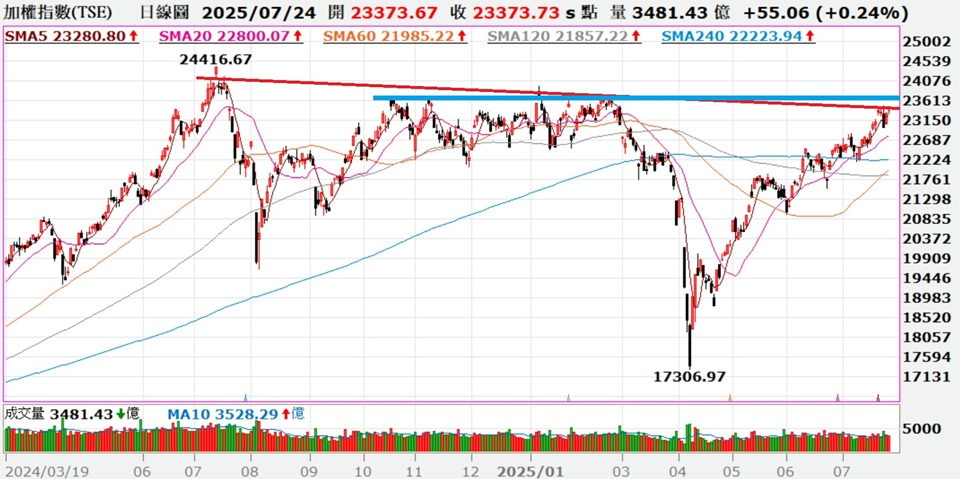  

In [5]:
def line_drawing_callback( range_prices) :

    seq_of_seq_of_points = []
    linewidths           = []
    colors               = []
    
    # 設定壓力線1
    resistance_line1_start_date  = '2024-07-05'
    resistance_line1_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    resistance_line1_x           = [mysys.DateToIndex(range_prices,'2024-07-11'),mysys.DateToIndex(range_prices,'2025-07-18')]
    resistance_line1_y           = [range_prices.loc['2024-07-11']['Low'],range_prices.loc['2025-07-18']['Close']]
    slope,intercept              = np.polyfit(resistance_line1_x,resistance_line1_y,1)
    resistance_line1_start_price = slope * mysys.DateToIndex(range_prices,resistance_line1_start_date) + intercept
    resistance_line1_end_price   = slope * mysys.DateToIndex(range_prices,resistance_line1_end_date) + intercept
    seq_of_seq_of_points.append([(resistance_line1_start_date,resistance_line1_start_price),(resistance_line1_end_date,resistance_line1_end_price)])
    linewidths.append(1.8)
    colors.append('xkcd:red')
    
    # 設定壓力線2
    resistance_line2_start_date  = '2024-10-15'
    resistance_line2_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    resistance_line2_price       = range_prices.loc['2025-01-07']['Close']
    seq_of_seq_of_points.append([(resistance_line2_start_date,resistance_line2_price),(resistance_line2_end_date,resistance_line2_price)])
    linewidths.append(1.0)
    colors.append('xkcd:bright blue')

    # NOTE : 無效值，解決線條顏色的問題
    colors.append('white')
    
    return seq_of_seq_of_points,linewidths,colors

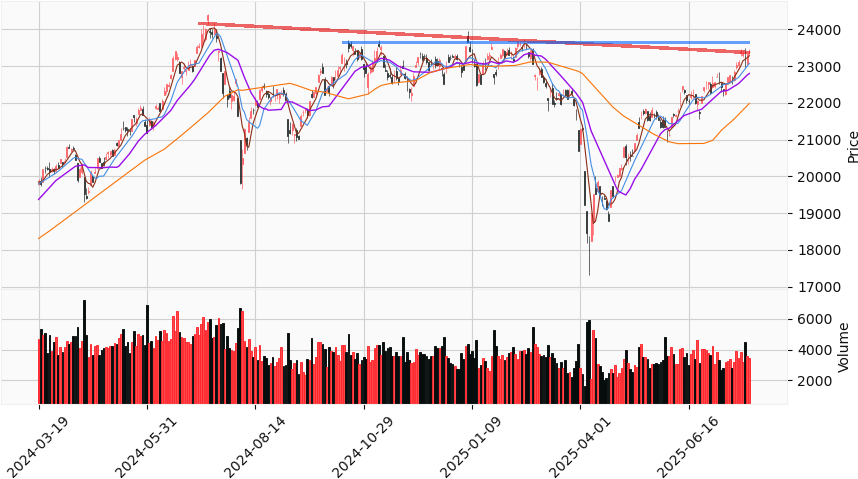

In [6]:
# 盤前：壓力線繪製
image = mysys.DrawOnKlineChart('TAIEX','2024-03-19','2025-07-24',line_drawing_callback)
display(image)

解盤內容：


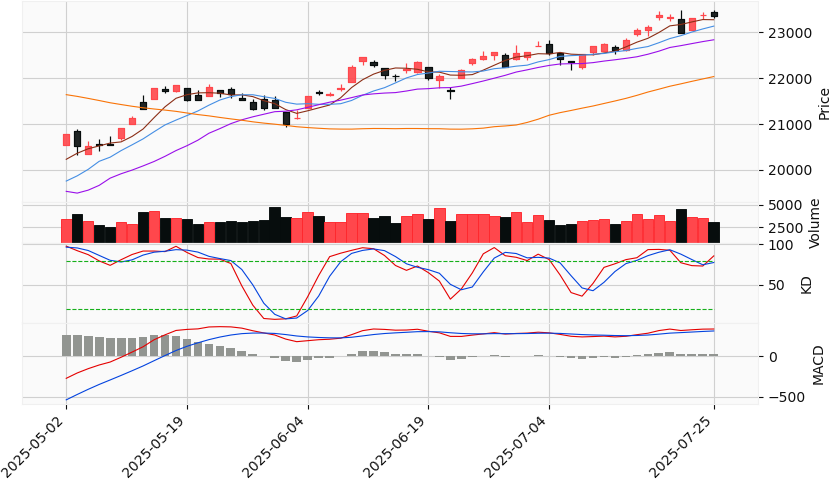

技術分析工具,解盤內容
Ｋ線／Ｋ棒,"紡錘線 : 2025-07-21 , 2025-07-24 十字線 : 2025-07-24 吞噬 : 2025-07-25"
Ｋ線圖,中期為高位階 長期為高位階
成交量,價量關係：未至大量門檻（成交量 ＝ 3025.59億元 ，十日均量 ＝ 3494.69億元）
型態,反轉型態之三重頂，型態範圍由2024-08-12開始到2025-03-03結束，估算目標價為21371.25。 底型反轉之底部型態，型態範圍由2025-04-02開始到2025-05-02結束，估算目標價為22257.56。
移動平均線,5日線下彎、10日線上揚，短期盤整；20日線上揚、60日線上揚，中期翻多；120日線下彎、240日線上揚，長期盤整
ＫＤ指標,於2025-07-25黃金交叉。
ＭＡＣＤ指標,MACD在零軸以上，中期多方
周Ｋ－周ＫＤ指標,於2025-06-23當周黃金交叉。並且2025-07-14該周在超買區。
整體評價,根據圖表進行技術分析如下： 價格趨勢 目前價格呈現上漲趨勢。K線圖顯示多數紅K，且價格持續高於5日、10日及20日移動平均線，顯示短期及中期趨勢均為上升。 價量關係 成交量在上漲過程中有增加的趨勢，顯示價量配合良好，支持上漲趨勢。 支撐與壓力 - 支撐位：20日移動平均線（紫色）及60日移動平均線（橙色）可視為支撐位。 - 壓力位：目前價格接近歷史高點，需注意可能的壓力。 KD指標解讀 KD指標顯示K線和D線在高檔區域，K線略高於D線，顯示短期內可能有超買現象，但尚未出現明顯的回檔信號。 MACD指標解讀 MACD指標中，DIF線高於MACD線，且灰色柱體（OSC）為正，顯示多頭趨勢持續。 綜合評價 整體來看，市場目前處於上升趨勢，價量配合良好，短期內可能會有小幅回檔，但中長期趨勢仍然看漲。建議投資者可考慮持有或逢低加碼，但需注意短期內的超買風險，設置適當的停損和停利點。


In [7]:
# 解盤：加權指數
stock_analysis(analysis,'TAIEX')

開盤：加權指數小漲，短線持續盤整。  
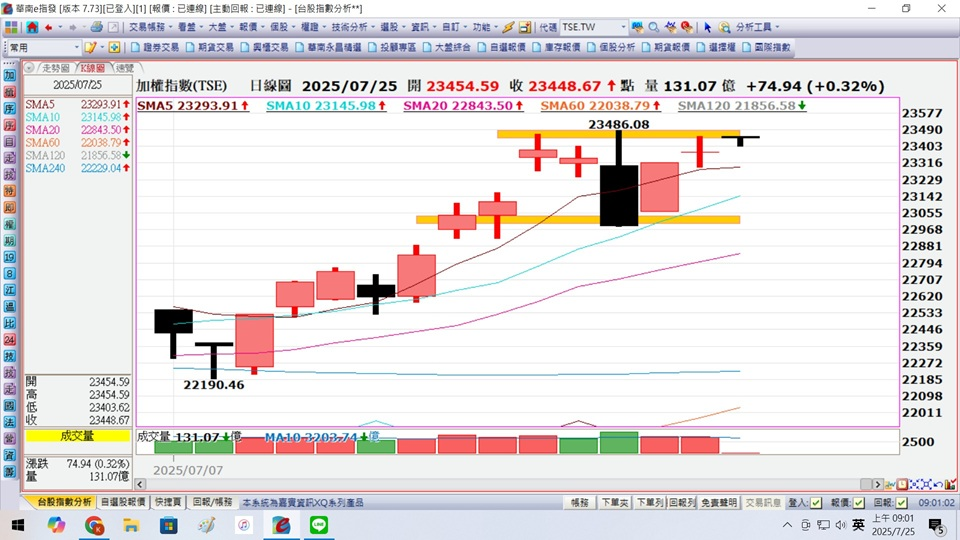  

In [8]:
def line_drawing_callback( range_prices) :

    seq_of_seq_of_points = []
    linewidths           = []
    colors               = []
    
    # 設定箱型壓力線
    resistance_line_start_date  = '2025-07-17'
    resistance_line_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    resistance_line_price       = range_prices.loc['2025-07-18']['High']
    seq_of_seq_of_points.append([(resistance_line_start_date,resistance_line_price),(resistance_line_end_date,resistance_line_price)])
    linewidths.append(2.5)
    colors.append('xkcd:orange yellow')
    
    # 設定箱型支撐線
    support_line_start_date  = '2025-07-15'
    support_line_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    support_line_price       = (range_prices.loc['2025-07-16']['Close'] + range_prices.loc['2025-07-22']['Close']) / 2
    seq_of_seq_of_points.append([(support_line_start_date,support_line_price),(support_line_end_date,support_line_price)])
    linewidths.append(3.0)
    colors.append('xkcd:orange yellow')

    return seq_of_seq_of_points,linewidths,colors

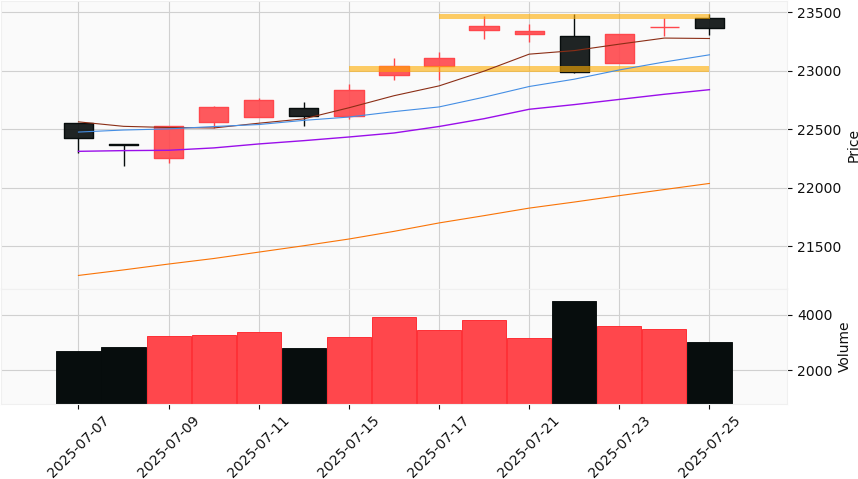

In [9]:
# 開盤：箱型區間繪製
image = mysys.DrawOnKlineChart('TAIEX','2025-07-07','2025-07-25',line_drawing_callback)
display(image)

* 櫃買指數  

盤前：櫃買指數中期持續盤整，長期偏空。  
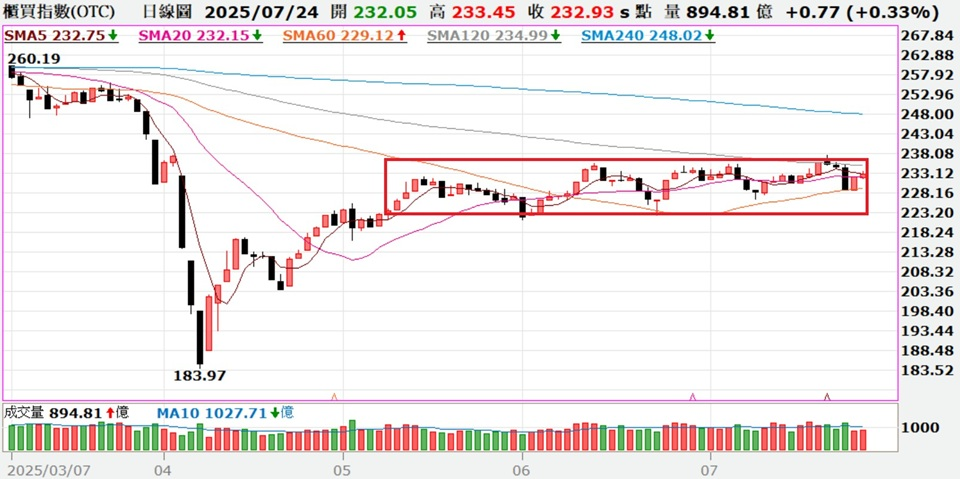  

In [10]:
def line_drawing_callback( range_prices) :

    seq_of_seq_of_points = []
    linewidths           = []
    colors               = []
    
    # 設定箱型壓力線
    resistance_line_start_date  = '2025-05-09'
    resistance_line_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    resistance_line_price       = range_prices.loc['2025-07-18']['Open']
    seq_of_seq_of_points.append([(resistance_line_start_date,resistance_line_price),(resistance_line_end_date,resistance_line_price)])
    linewidths.append(1.0)
    colors.append('xkcd:red')

    # 設定箱型支撐線
    support_line_start_date  = '2025-05-09'
    support_line_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    support_line_price       = range_prices.loc['2025-06-04']['Open']
    seq_of_seq_of_points.append([(support_line_start_date,support_line_price),(support_line_end_date,support_line_price)])
    linewidths.append(1.0)
    colors.append('xkcd:red')

    return seq_of_seq_of_points,linewidths,colors

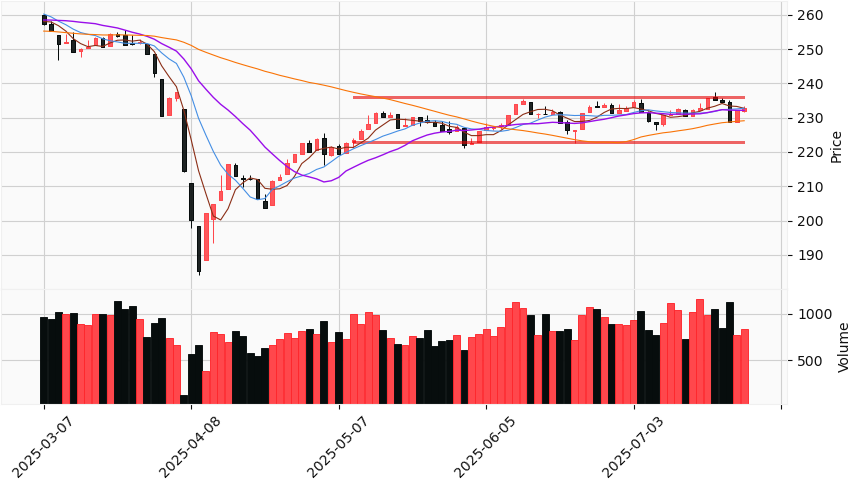

In [11]:
# 盤前：箱型區間繪製
image = mysys.DrawOnKlineChart('TPEx','2025-03-07','2025-07-24',line_drawing_callback)
display(image)

解盤內容：


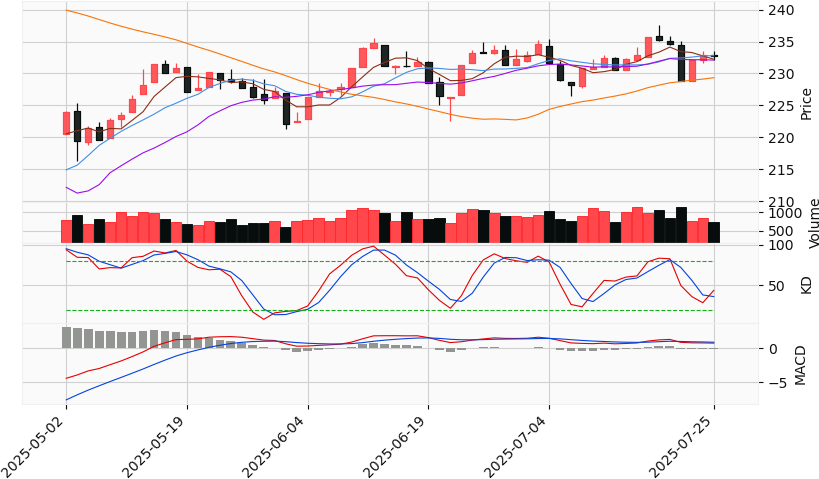

技術分析工具,解盤內容
Ｋ線／Ｋ棒,"紡錘線 : 2025-07-25 十字線 : 2025-07-25 墓碑線 : 2025-07-21 , 2025-07-21 , 2025-07-21 , 2025-07-21 , 2025-07-21"
Ｋ線圖,中期為中位階 長期為中位階
成交量,價量關係：未至大量門檻（成交量 ＝ 732.7億元 ，十日均量 ＝ 926.42億元）
型態,盤整型態之三角形，型態範圍由2024-07-11開始到2025-03-28結束。 底型反轉之底部型態，型態範圍由2025-04-02開始到2025-05-02結束，估算目標價為247.79。
移動平均線,5日線下彎、10日線上揚，短期盤整；20日線下彎、60日線上揚，中期盤整；120日線下彎、240日線下彎，長期翻空
ＫＤ指標,於2025-07-25黃金交叉。
ＭＡＣＤ指標,MACD在零軸以上，中期多方
周Ｋ－周ＫＤ指標,於2025-06-02當周死亡交叉。
整體評價,價格趨勢 目前價格呈現盤整狀態。K線在短期移動平均線（5日、10日）附近波動，並且中期移動平均線（20日、60日）走平，顯示市場缺乏明顯的方向性。 價量關係 成交量在近期波動不大，未見明顯放量或縮量現象，顯示市場觀望情緒較重，買賣雙方力量相對均衡。 支撐與壓力 支撐位置大約在230點附近，壓力位置則在235點左右。價格多次在這兩個位置之間波動，顯示這些位置的支撐與壓力較為明顯。 KD指標解讀 KD指標顯示K線與D線在50附近交錯，並未進入超買或超賣區域，顯示市場短期內可能繼續盤整。 MACD指標解讀 MACD指標中，DIF線與MACD線接近零軸，且柱狀體顯示動能較弱，進一步支持盤整的判斷。 綜合評價 整體來看，市場目前處於盤整階段，短期內缺乏明顯的趨勢方向。建議投資者保持觀望，等待價格突破支撐或壓力位置後再行操作。若價格突破235點，可能會有進一步上漲空間；若跌破230點，則需注意下行風險。


In [12]:
# 解盤：櫃買指數
stock_analysis(analysis,'TPEx')

開盤：櫃買指數還在小的箱型區間。  
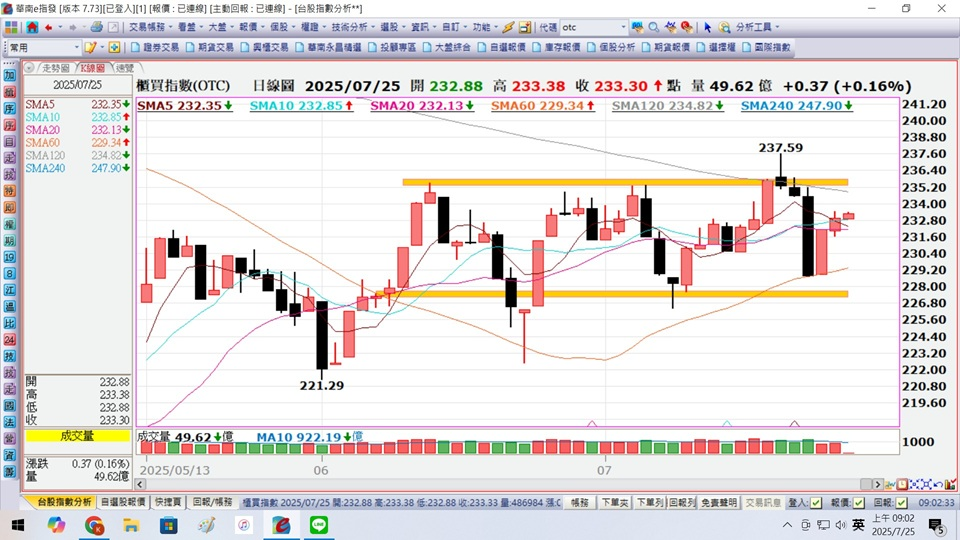  

In [13]:
def line_drawing_callback( range_prices) :

    seq_of_seq_of_points = []
    linewidths           = []
    colors               = []
    
    # 設定箱型壓力線
    resistance_line_start_date  = '2025-06-10'
    resistance_line_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    resistance_line_price       = range_prices.loc['2025-06-12']['High']
    seq_of_seq_of_points.append([(resistance_line_start_date,resistance_line_price),(resistance_line_end_date,resistance_line_price)])
    linewidths.append(2.5)
    colors.append('xkcd:orange yellow')
    
    # 設定箱型支撐線
    support_line_start_date  = '2025-06-06'
    support_line_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    support_line_price       = range_prices.loc['2025-06-09']['Open']
    seq_of_seq_of_points.append([(support_line_start_date,support_line_price),(support_line_end_date,support_line_price)])
    linewidths.append(2.5)
    colors.append('xkcd:orange yellow')

    return seq_of_seq_of_points,linewidths,colors

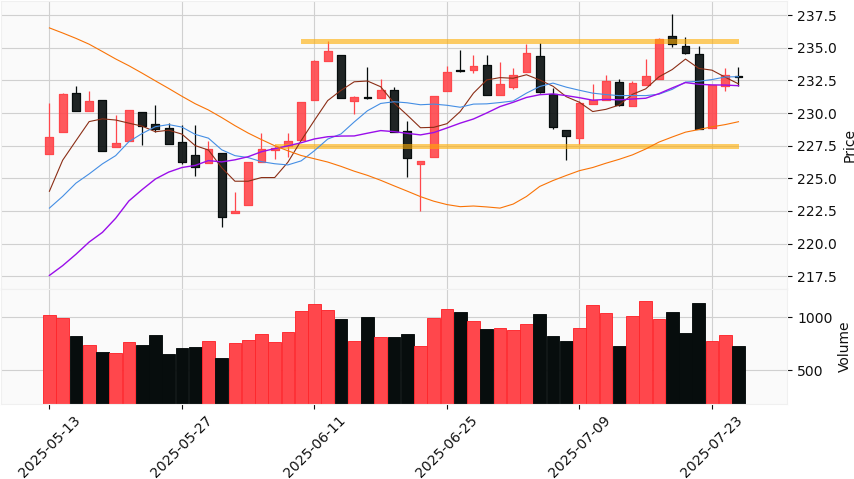

In [14]:
# 開盤：箱型區間繪製
image = mysys.DrawOnKlineChart('TPEx','2025-05-13','2025-07-25',line_drawing_callback)
display(image)

### 個股解盤  

* 台塑(1301)  
  看法：仍在打底，籌碼尚未轉強。  

解盤內容：


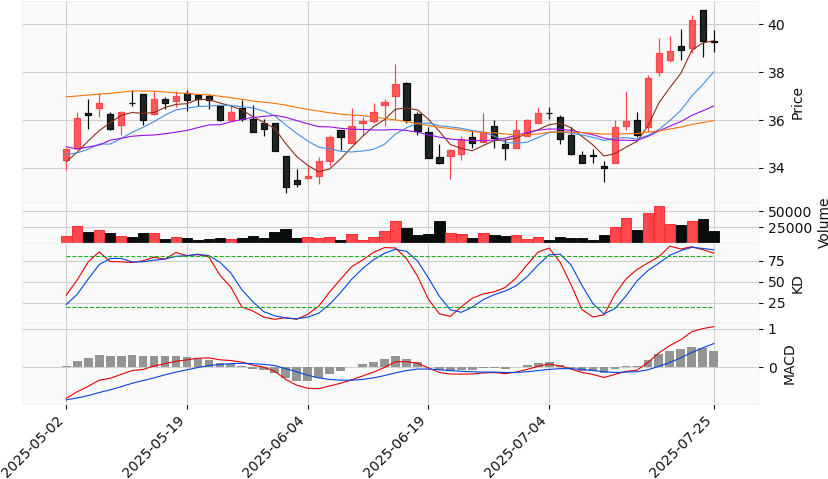

技術分析工具,解盤內容
Ｋ線／Ｋ棒,"紡錘線 : 2025-07-22 , 2025-07-25 十字線 : 2025-07-25"
Ｋ線圖,中期為高位階 長期為中位階
成交量,價量關係：未至大量門檻（成交量 ＝ 20062張 ，十日均量 ＝ 34270張）
型態,中繼型態之上升旗形，型態範圍由2025-01-10開始到2025-07-24結束。
移動平均線,5日線上揚、10日線上揚，短期翻多；20日線上揚、60日線上揚，中期翻多；120日線上揚、240日線下彎，長期盤整
ＫＤ指標,於2025-07-24死亡交叉。並且2025-07-25於超買區。
ＭＡＣＤ指標,MACD在零軸以上，中期多方
周Ｋ－周ＫＤ指標,於2025-07-14當周黃金交叉。
整體評價,根據圖表進行技術分析如下： 價格趨勢 近期價格呈現上漲趨勢，尤其在最近幾個交易日中，價格突破了多條移動平均線，顯示出強勁的上升動能。 價量關係 成交量在價格上漲時明顯增加，顯示出多頭的強勢。這種價量配合通常預示著上漲趨勢的延續。 支撐與壓力 - 支撐位：短期支撐位可參考10日移動平均線（天藍色），約在38元附近。 - 壓力位：近期高點約在40元以上，可能形成短期壓力。 KD指標解讀 KD指標顯示K線和D線均位於超買區域，且K線略微下彎，顯示出短期內可能有回檔壓力。 MACD指標解讀 MACD指標中，DIF線在MACD線之上，且灰色柱體持續增長，顯示出多頭趨勢仍然強勁。 綜合評價 整體來看，市場目前處於上升趨勢中，價量配合良好。然而，由於KD指標顯示超買，短期內可能會有回檔壓力。建議投資者在短期內謹慎操作，考慮在支撐位附近進行佈局，並設置適當的停損點以控制風險。中長期來看，若能有效突破壓力位，則有望進一步上行。


In [15]:
stock_analysis(analysis,'1301')

In [16]:
def line_drawing_callback( range_prices) :
    # 設定頸線
    neckline_start_date = '2024-11-29'
    neckline_end_date   = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    neckline_price      = range_prices.loc['2025-03-21']['Open']

    # 設定底部到頸線差距
    bottom_date  = '2025-01-10'
    bottom_price = range_prices.loc['2025-01-10']['Close']

    # 估算目標價
    target_price = (neckline_price - bottom_price) + neckline_price

    print('估算目標價為{:.2f}元'.format(target_price))

    seq_of_seq_of_points=[
        [(neckline_start_date,neckline_price),(neckline_end_date,neckline_price)],
        [(bottom_date,bottom_price),(bottom_date,neckline_price)],
        [(neckline_end_date,neckline_price),(neckline_end_date,target_price)],
    ]

    linewidths=[2.0,15.0,15.0]
    
    colors=['xkcd:orange yellow','xkcd:orange yellow','xkcd:orange yellow']

    return seq_of_seq_of_points,linewidths,colors

In [17]:
image = mysys.DrawOnKlineChart('1301','2024-09-20','2025-07-25',line_drawing_callback)

估算目標價為49.55元


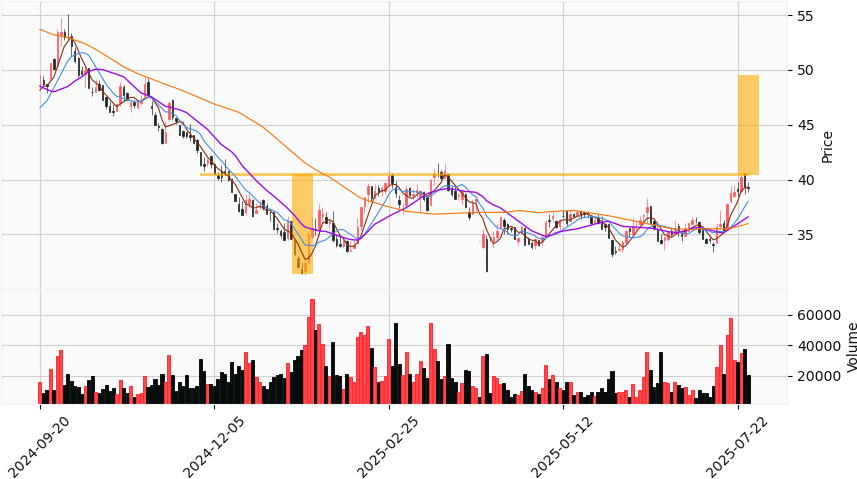

In [18]:
display(image)

籌碼面：  
法人中立(+84)：外資小買(+1114)、投信小賣(-126)、自營小賣(-904)。  
主力小買(+587)。  
分公司買賣家數差分散(-10)。  
融資增(+317)、融券增(+60)。  

* 中鋼(2002)  
  看法：測頸線有守，尚未轉強。往上反壓多。  

解盤內容：


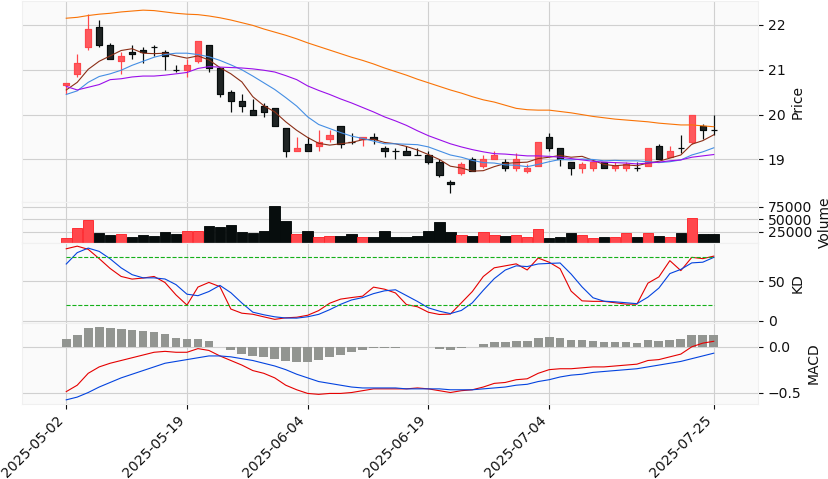

技術分析工具,解盤內容
Ｋ線／Ｋ棒,"紡錘線 : 2025-07-22 , 2025-07-25 十字線 : 2025-07-22 , 2025-07-25 孕育線／懷抱線 : 2025-07-21 , 2025-07-24"
Ｋ線圖,中期為中位階 長期為中位階
成交量,價量關係：未至大量門檻（成交量 ＝ 19917張 ，十日均量 ＝ 22147張）
型態,底型反轉之底部型態，型態範圍由2025-04-02開始到2025-05-06結束，估算目標價為23.55。
移動平均線,5日線上揚、10日線上揚，短期翻多；20日線上揚、60日線下彎，中期盤整；120日線下彎、240日線下彎，長期翻空
ＫＤ指標,於2025-07-23黃金交叉。
ＭＡＣＤ指標,MACD在零軸以下，中期空方
周Ｋ－周ＫＤ指標,於2025-06-23當周黃金交叉。
整體評價,價格趨勢 近期股價呈現反彈跡象，短期移動平均線（5日、10日）開始上揚，並且股價已突破20日移動平均線，顯示短期有上漲動能。然而，60日移動平均線仍然向下，顯示中期趨勢尚未完全扭轉。 價量關係 近期成交量有所增加，尤其在股價上漲時，成交量同步放大，顯示多頭動能增強，價量配合良好。 支撐與壓力 目前股價在20元附近有壓力，若能有效突破，將有機會挑戰更高的價位。下方支撐可參考19元附近，若跌破此支撐，可能會回檔。 KD指標解讀 KD指標中的K線已進入超買區域，並高於D線，顯示短期內仍有上漲空間，但需留意可能的回檔風險。 MACD指標解讀 MACD指標中的DIF線位於MACD線之上，且灰色柱體（OSC）持續增長，顯示多頭趨勢增強，短期內有利於股價上行。 綜合評價 綜合以上分析，短期內股價有望繼續上漲，但需注意20元的壓力位。若能突破此壓力，將有更大上行空間。投資者可考慮在突破後進行追多操作，並設置適當的停損點以控制風險。中期趨勢仍需觀察60日移動平均線的變化。


In [19]:
stock_analysis(analysis,'2002')

In [20]:
def line_drawing_callback( range_prices) :
    # 設定頸線
    neckline_start_date = '2025-05-28'
    neckline_end_date   = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    neckline_price      = range_prices.loc['2025-06-06']['High']

    # 設定底部到頸線差距
    bottom_date  = '2025-06-23'
    bottom_price = range_prices.loc['2025-06-23']['Close']

    # 估算目標價
    target_price = (neckline_price - bottom_price) + neckline_price

    print('估算目標價為{:.2f}元'.format(target_price))

    seq_of_seq_of_points=[
        [(neckline_start_date,neckline_price),(neckline_end_date,neckline_price)],
        [(bottom_date,bottom_price),(bottom_date,neckline_price)],
        [(neckline_end_date,neckline_price),(neckline_end_date,target_price)],
    ]

    linewidths=[2.0,15.0,15.0]
    
    colors=['xkcd:orange yellow','xkcd:orange yellow','xkcd:orange yellow']

    return seq_of_seq_of_points,linewidths,colors

In [21]:
image = mysys.DrawOnKlineChart('2002','2025-03-31','2025-07-25',line_drawing_callback)

估算目標價為20.85元


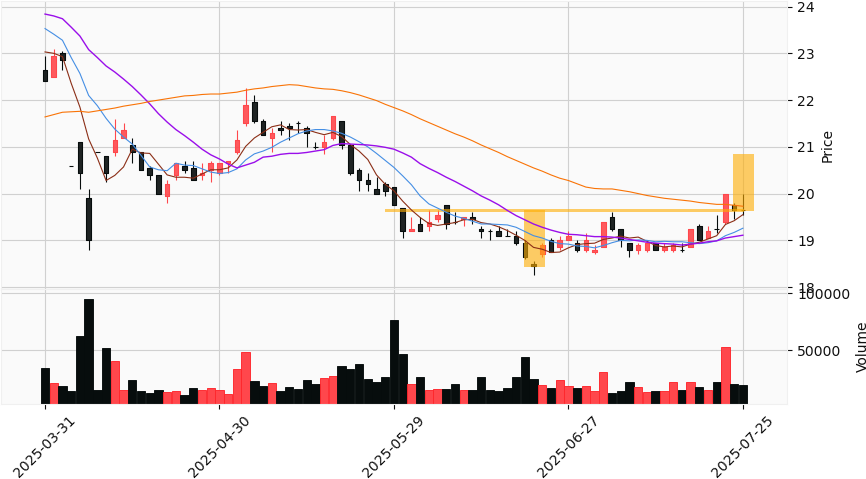

In [22]:
display(image)

籌碼面：  
法人小買(+2903)：外資小買(+3635)、投信小賣(-342)、自營小賣(-390)。  
主力小買(+1393)。  
分公司買賣家數差集中(+13)。  
融資大增(+1233)、融券增(+20)。  